# RNA-seq Differential Expression Analysis with pyDESeq2

This notebook reproduces the treatment vs control DE workflow from the R DESeq2 report using Python and pyDESeq2.

## 1. Setup
Install dependencies if needed, then import libraries.

Using conda (microforge recommended) and pip, you can install the required packages with the following commands:

```bash
conda create -n pydeseq2 python pip
conda activate pydeseq2
pip install pydeseq2 pandas numpy matplotlib seaborn scipy ipykernel
```

In [ ]:

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from scipy.stats import zscore

sns.set_context("notebook")
sns.set_style("whitegrid")

## 2. Load counts and metadata

Expected files:
- `data/nf-core_rnaseq/salmon.merged.gene_counts.tsv`
- `data/metadata/metadata.tsv`

In [2]:
project_root = Path.cwd().resolve()
if not (project_root / ".git").exists():
    # Support running from subfolders
    for parent in [project_root, *project_root.parents]:
        if (parent / ".git").exists():
            project_root = parent
            break

counts_path = project_root / "data" / "nf-core_rnaseq" / "salmon.merged.gene_counts.tsv"
meta_path = project_root / "data" / "metadata" / "metadata.tsv"

counts_raw = pd.read_csv(counts_path, sep="\t")
metadata = pd.read_csv(meta_path, sep="\t")

print("Counts matrix shape (raw):", counts_raw.shape)
print("Metadata shape:", metadata.shape)
display(metadata.head())

Counts matrix shape (raw): (4523, 8)
Metadata shape: (6, 3)


,sample,group,replicate
0,C1,control,1
1,C2,control,2
2,C3,control,3
3,sac1,treatment,1
4,sac2,treatment,2


## 3. Build pyDESeq2 inputs

pyDESeq2 expects:
- `counts`: samples x genes integer count matrix
- `metadata`: sample-level design table indexed by sample IDs

The nf-core merged table may contain non-integer estimated counts; we round to nearest integer for DE modeling.

In [3]:
# Align metadata and count columns
metadata = metadata.rename(columns={"group": "condition"}).copy()
metadata["sample"] = metadata["sample"].astype(str)
metadata["condition"] = pd.Categorical(
    metadata["condition"], categories=["control", "treatment"], ordered=True
)
metadata = metadata.set_index("sample")

sample_cols = metadata.index.tolist()
required_cols = {"gene_id", "gene_name", *sample_cols}
missing = required_cols.difference(counts_raw.columns)
if missing:
    raise ValueError(f"Missing expected columns in counts file: {sorted(missing)}")

counts_genes = counts_raw.set_index("gene_id")[sample_cols]

# Convert to integer counts for DESeq2-like NB model
counts_genes = counts_genes.apply(pd.to_numeric, errors="coerce").fillna(0)
counts_genes_int = counts_genes.round().astype(int)

# pyDESeq2 needs samples x genes
counts_py = counts_genes_int.T

print("Counts for pyDESeq2 (samples x genes):", counts_py.shape)
print("Conditions:", metadata["condition"].value_counts().to_dict())
display(counts_py.iloc[:3, :5])

Counts for pyDESeq2 (samples x genes): (6, 4523)
Conditions: {'control': 3, 'treatment': 3}


gene_id,b0001,b0002,b0003,b0004,b0005
C1,0,2754,1086,1852,4
C2,0,2375,899,1484,4
C3,1,8667,4300,7284,3


## 4. Run pyDESeq2

Contrast: treatment vs control

In [4]:
dds = DeseqDataSet(
    counts=counts_py,
    metadata=metadata[["condition"]],
    design_factors="condition",
    refit_cooks=True,
)
dds.deseq2()

stats = DeseqStats(dds, contrast=["condition", "treatment", "control"])
stats.summary()

res_df = stats.results_df.copy()
res_df.index.name = "gene"
res_df = res_df.reset_index().sort_values("padj", na_position="last")
display(res_df.head())

Using None as control genes, passed at DeseqDataSet initialization


/var/folders/l5/nswv371n67s9yhyshhkmwm140000gp/T/ipykernel_80009/2790062758.py:1: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.26 seconds.

Fitting dispersion trend curve...
... done in 0.05 seconds.

Fitting MAP dispersions...
... done in 0.29 seconds.

Fitting LFCs...
... done in 0.23 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: condition treatment vs control
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
gene_id                                                                     
b0001       0.242467        0.047564  4.218982  0.011274  0.991005       NaN
b0002    4677.428457        0.460619  0.137488  3.350254  0.000807  0.003139
b0003    1706.465150        0.079469  0.149698  0.530862  0.595515  0.727744
b0004    2779.425776       -0.015164  0.151088 -0.100363  0.920056  0.951329
b0005       7.256502        1.246985  0.886119  1.407242  0.159356  0.275502
...              ...             ...       ...       ...       ...       ...
b4842      21.562554        0.156891  0.474505  0.330642  0.740915  0.840133
b4843       1.258881        2.189576  2.148901  1.018928  0.308237       NaN
b4844       0.835434        1.338228  2.534135  0.528081  0.597443       NaN
b4845       0.000000             NaN       NaN       NaN       NaN       NaN
b4846  

... done in 0.21 seconds.



,gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
881,b0929,19765.111534,-7.874616,0.195661,-40.246201,0.000000e+00,0.000000e+00
3322,b3508,1228.424574,5.604013,0.197115,28.430178,8.569095e-178,1.707392e-174
3324,b3510,21867.398485,4.892153,0.173702,28.164112,1.609793e-174,2.138342e-171
2957,b3125,1496.336331,-3.630282,0.140805,-25.782327,1.399689e-146,1.394440e-143
1413,b1492,26827.611923,6.294774,0.246271,25.560381,4.209541e-144,3.355004e-141


## 5. LFC shrinkage and significant genes

Use shrunken log2 fold changes for ranking and plotting.

In [5]:
stats

In [6]:
# pyDESeq2 shrinkage updates stats.results_df
stats.lfc_shrink(coeff="condition[T.treatment]")
res_shrunk = stats.results_df.copy()
res_shrunk.index.name = "gene"
res_shrunk = res_shrunk.reset_index().sort_values("padj", na_position="last")

res_shrunk = res_shrunk.dropna(subset=["padj"])
res_sig = res_shrunk[
    (res_shrunk["padj"] < 0.05) & (res_shrunk["log2FoldChange"].abs() >= 1)
].copy()

print("Total genes tested      :", len(res_shrunk))
print("Significant genes       :", len(res_sig))
print("Upregulated (LFC >= 1) :", int((res_sig["log2FoldChange"] >= 1).sum()))
print("Downregulated (LFC <= -1):", int((res_sig["log2FoldChange"] <= -1).sum()))
display(res_sig.head(10))

Fitting MAP LFCs...


Shrunk log2 fold change & Wald test p-value: condition[T.treatment]
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
gene_id                                                                     
b0001       0.242467        0.020381  1.043887  0.011274  0.991005       NaN
b0002    4677.428457        0.446029  0.136769  3.350254  0.000807  0.003139
b0003    1706.465150        0.075119  0.147933  0.530862  0.595515  0.727744
b0004    2779.425776       -0.014674  0.149242 -0.100363  0.920056  0.951329
b0005       7.256502        0.531635  0.807001  1.407242  0.159356  0.275502
...              ...             ...       ...       ...       ...       ...
b4842      21.562554        0.107871  0.425308  0.330642  0.740915  0.840133
b4843       1.258881        0.239028  1.235740  1.018928  0.308237       NaN
b4844       0.835434        0.080251  1.076789  0.528081  0.597443       NaN
b4845       0.000000             NaN       NaN       NaN       NaN       NaN
b4846   

... done in 0.29 seconds.



,gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
881,b0929,19765.111534,-7.864681,0.195897,-40.246201,0.000000e+00,0.000000e+00
3322,b3508,1228.424574,5.590915,0.196947,28.430178,8.569095e-178,1.707392e-174
3324,b3510,21867.398485,4.880574,0.173821,28.164112,1.609793e-174,2.138342e-171
2957,b3125,1496.336331,-3.620079,0.140887,-25.782327,1.399689e-146,1.394440e-143
1413,b1492,26827.611923,6.276711,0.246528,25.560381,4.209541e-144,3.355004e-141
520,b0553,5678.679707,-4.114914,0.161648,-25.547100,5.913548e-144,3.927581e-141
2959,b3127,1062.291522,-6.918815,0.271269,-25.514942,1.345762e-143,7.661230e-141
3323,b3509,8083.623360,4.845863,0.193370,25.180784,6.504783e-140,3.240195e-137
1414,b1493,28137.085544,6.648790,0.270012,24.711319,8.082153e-135,3.578598e-132
3328,b3514,5001.548151,5.313928,0.216839,24.605194,1.111428e-133,4.429040e-131


## 6. Volcano and MA plots

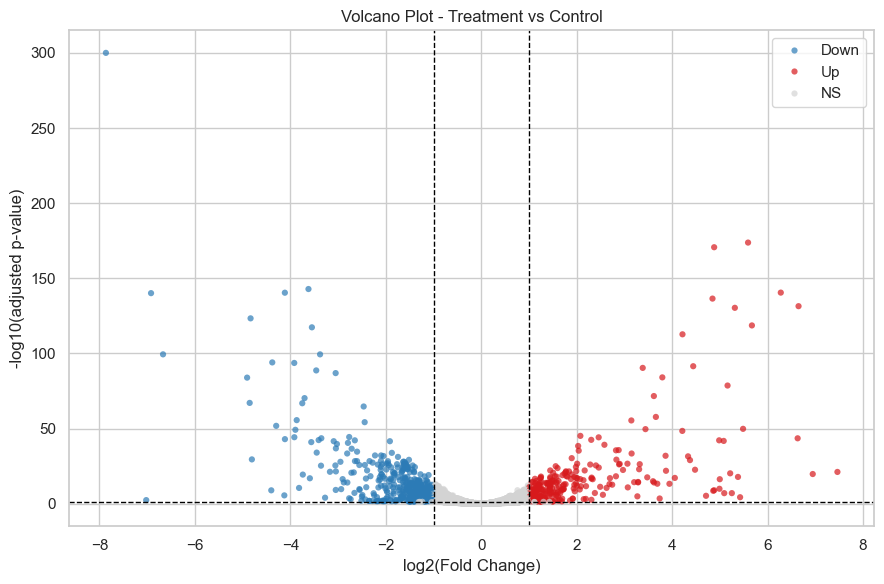

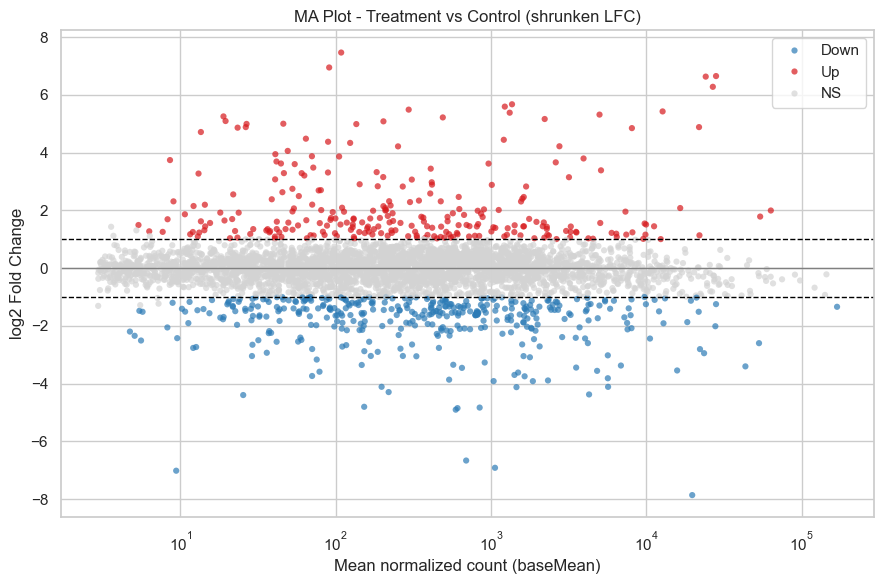

In [7]:
plot_df = res_shrunk.copy()
plot_df["significance"] = np.where(
    (plot_df["padj"] < 0.05) & (plot_df["log2FoldChange"] >= 1),
    "Up",
    np.where(
        (plot_df["padj"] < 0.05) & (plot_df["log2FoldChange"] <= -1), "Down", "NS"
    ),
)
plot_df["neglog10_padj"] = -np.log10(plot_df["padj"].clip(lower=1e-300))

fig, ax = plt.subplots(figsize=(9, 6))
palette = {"Up": "#d7191c", "Down": "#2c7bb6", "NS": "lightgray"}
sns.scatterplot(
    data=plot_df,
    x="log2FoldChange",
    y="neglog10_padj",
    hue="significance",
    palette=palette,
    alpha=0.7,
    s=20,
    linewidth=0,
    ax=ax,
)
ax.axvline(-1, ls="--", c="black", lw=1)
ax.axvline(1, ls="--", c="black", lw=1)
ax.axhline(-np.log10(0.05), ls="--", c="black", lw=1)
ax.set_title("Volcano Plot - Treatment vs Control")
ax.set_xlabel("log2(Fold Change)")
ax.set_ylabel("-log10(adjusted p-value)")
plt.legend(title="")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=plot_df,
    x="baseMean",
    y="log2FoldChange",
    hue="significance",
    palette=palette,
    alpha=0.7,
    s=20,
    linewidth=0,
    ax=ax,
)
ax.set_xscale("log")
ax.axhline(-1, ls="--", c="black", lw=1)
ax.axhline(1, ls="--", c="black", lw=1)
ax.axhline(0, ls="-", c="gray", lw=1)
ax.set_title("MA Plot - Treatment vs Control (shrunken LFC)")
ax.set_xlabel("Mean normalized count (baseMean)")
ax.set_ylabel("log2 Fold Change")
plt.legend(title="")
plt.tight_layout()
plt.show()

## 7. Top gene count plot and heatmap

Uses normalized counts from pyDESeq2 output object.

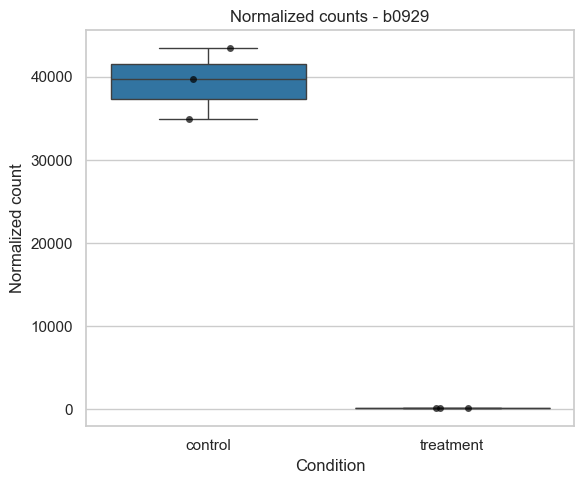

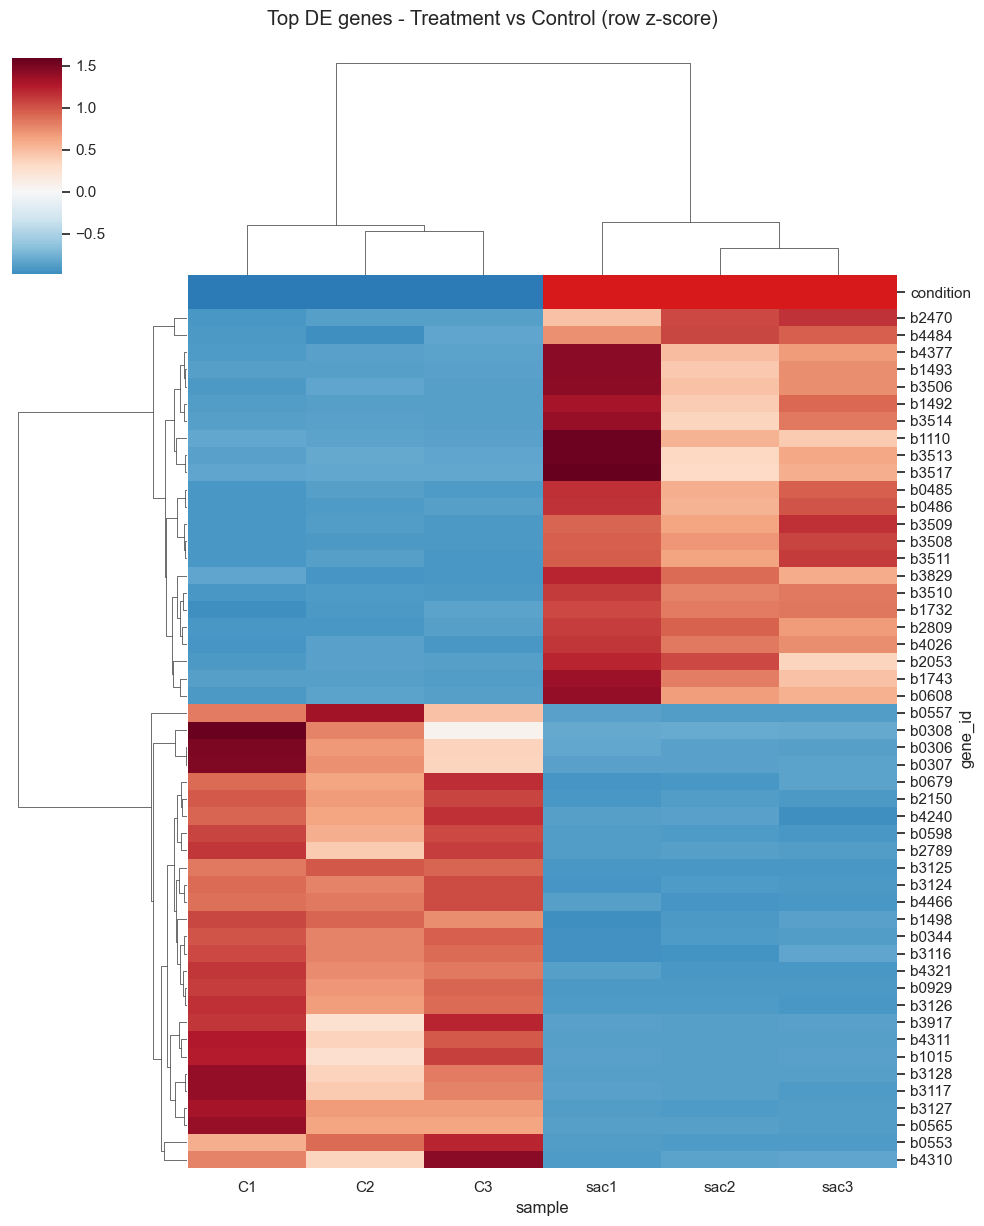

In [8]:
def get_norm_counts(dds_obj):
    if hasattr(dds_obj, "layers") and "normed_counts" in dds_obj.layers:
        arr = dds_obj.layers["normed_counts"]
        return pd.DataFrame(arr, index=dds_obj.obs_names, columns=dds_obj.var_names)
    if hasattr(dds_obj, "normed_counts"):
        arr = dds_obj.normed_counts
        return pd.DataFrame(arr, index=dds_obj.obs_names, columns=dds_obj.var_names)
    raise AttributeError("Could not find normalized counts in dds object.")


norm_counts = get_norm_counts(dds)

if len(res_sig) > 0:
    top_gene = res_sig.iloc[0]["gene"]
    top_gene_df = norm_counts[[top_gene]].join(metadata[["condition"]])

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.boxplot(data=top_gene_df, x="condition", y=top_gene, ax=ax)
    sns.stripplot(
        data=top_gene_df, x="condition", y=top_gene, color="black", alpha=0.7, ax=ax
    )
    ax.set_title(f"Normalized counts - {top_gene}")
    ax.set_xlabel("Condition")
    ax.set_ylabel("Normalized count")
    plt.tight_layout()
    plt.show()

    top_n = min(50, len(res_sig))
    top_genes = res_sig.head(top_n)["gene"].tolist()
    heat_df = norm_counts[top_genes].T
    heat_df = (
        heat_df.apply(
            lambda s: pd.Series(zscore(s, ddof=1), index=s.index),
            axis=1,
            raw=False,
            result_type="expand",
        )
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

    col_colors = metadata["condition"].map(
        {"control": "#2c7bb6", "treatment": "#d7191c"}
    )
    sns.clustermap(
        heat_df,
        cmap="RdBu_r",
        center=0,
        col_colors=col_colors,
        xticklabels=True,
        yticklabels=True,
        figsize=(10, 12),
    )
    plt.suptitle("Top DE genes - Treatment vs Control (row z-score)", y=1.02)
    plt.show()
else:
    print("No significant genes at padj < 0.05 and |log2FC| >= 1.")

## 8. Save pyDESeq2 results

In [9]:
results_dir = project_root / "results"
results_dir.mkdir(parents=True, exist_ok=True)

all_out = results_dir / "DE_treatment_vs_control_all_pydeseq2.tsv"
sig_out = results_dir / "DE_treatment_vs_control_significant_pydeseq2.tsv"

res_shrunk.to_csv(all_out, sep="\t", index=False)
res_sig.to_csv(sig_out, sep="\t", index=False)

print("Saved:", all_out)
print("Saved:", sig_out)

Saved: /Users/heweb/Documents/repos/dsp_transcriptomics_training/results/DE_treatment_vs_control_all_pydeseq2.tsv
Saved: /Users/heweb/Documents/repos/dsp_transcriptomics_training/results/DE_treatment_vs_control_significant_pydeseq2.tsv


## 9. Optional comparison with existing R DESeq2 output

In [10]:
r_sig_path = project_root / "results" / "DE_treatment_vs_control_significant.tsv"
if r_sig_path.exists():
    r_sig = pd.read_csv(r_sig_path, sep="\t")
    overlap = len(set(r_sig["gene"]).intersection(set(res_sig["gene"])))
    print("R DESeq2 significant genes:", len(r_sig))
    print("pyDESeq2 significant genes:", len(res_sig))
    print("Overlap:", overlap)
else:
    print("R DESeq2 significant file not found, skipping comparison.")

R DESeq2 significant genes: 646
pyDESeq2 significant genes: 650
Overlap: 633
